# 02 · Empirical validation — stylized facts  (Paper §4.2, SF1–SF3)

**The paper's SF1–SF3 numbers are the stored result `emp-valid/stylized_facts_comparison.csv`** (median 1.232 / 0.021 / 0.643), recomputed once from the *baseline* HK($p_t{=}0.3$, $\mu{=}0.8$, $\epsilon_s{=}0.5$) batch of `results/run_*` and the empirical anchors in `docs/report/sf*_empirical_anchor.html`.

This notebook **presents** that stored result (table + figure). The original computation from the raw per-run metrics + repost GEXF is preserved at the bottom under `RECOMPUTE=False`; it is guarded off because the transient `results/run_*` directories are regenerated by later experiments and no longer hold the baseline batch, so re-running would **not** reproduce the paper values. To truly recompute, regenerate the baseline runs (`run.sh` with the baseline `config.yaml`) first, then set `RECOMPUTE=True`.

In [1]:
# --- bootstrap: run from anywhere; cd to repo root ---
import os
for _ in range(5):
    if os.path.isdir('results') and os.path.isdir('src'):
        break
    os.chdir('..')
print('working dir:', os.getcwd())

working dir: /home/tomoyatakeda/document/research/manipulation-backfire-model


In [2]:
import pandas as pd, numpy as np
sf_df = pd.read_csv('emp-valid/stylized_facts_comparison.csv')
print(sf_df[['fact_id','stylized_fact','empirical_low','empirical_high',
             'model_median','model_iqr_low','model_iqr_high','match']].to_string(index=False))

fact_id                                                          stylized_fact  empirical_low  empirical_high  model_median  model_iqr_low  model_iqr_high         match
    SF1            Posting distribution more extreme than opinion distribution           1.19            1.26         1.232          1.185           1.286         match
    SF2 Repost network strongly segregated; cross-partisan reposting near-zero           0.00            0.07         0.021          0.006           0.043         match
    SF3             Partial echo chambers (majority-aligned) for engaged users           0.65            0.76         0.643          0.577           0.701 outside range


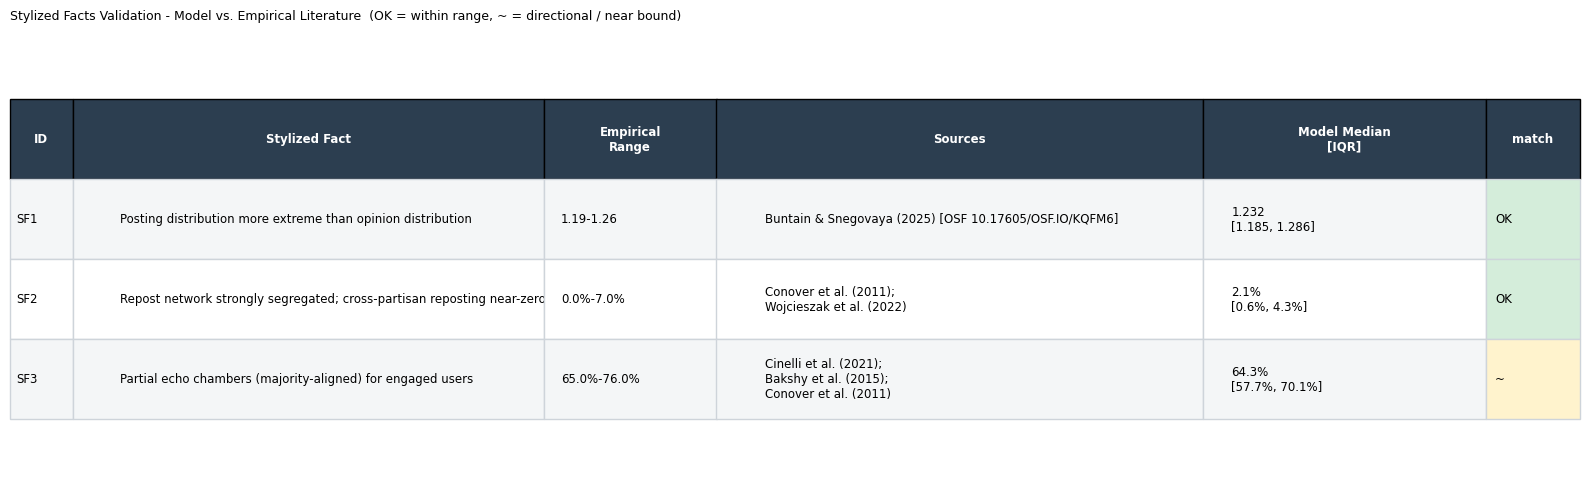

Saved: emp-valid/stylized_facts_table.png


In [3]:
import matplotlib.pyplot as plt

def fmt_pct(v):   return f"{v*100:.1f}%" if not (isinstance(v,float) and np.isnan(v)) else "N/A"
def fmt_ratio(v): return f"{v:.3f}"     if not (isinstance(v,float) and np.isnan(v)) else "N/A"

table_data = []
for _, r in sf_df.iterrows():
    unit = str(r["unit"])
    if "ratio" in unit:
        emp_range = f"{r['empirical_low']:.2f}-{r['empirical_high']:.2f}"
        model_val = (f"{fmt_ratio(r['model_median'])}\n"
                     f"[{fmt_ratio(r['model_iqr_low'])}, {fmt_ratio(r['model_iqr_high'])}]")
    else:
        emp_range = f"{fmt_pct(r['empirical_low'])}-{fmt_pct(r['empirical_high'])}"
        model_val = (f"{fmt_pct(r['model_median'])}\n"
                     f"[{fmt_pct(r['model_iqr_low'])}, {fmt_pct(r['model_iqr_high'])}]")
    sources = str(r["sources"]).replace("; ", ";\n")
    match_sym = "OK" if r["match"] == "match" else "~"
    table_data.append([r["fact_id"], r["stylized_fact"], emp_range, sources, model_val, match_sym])

col_labels = ["ID","Stylized Fact","Empirical\nRange","Sources","Model Median\n[IQR]","match"]
col_widths = [0.04, 0.30, 0.11, 0.31, 0.18, 0.06]
fig, ax = plt.subplots(figsize=(16, 0.8 + len(table_data)*1.4)); ax.axis("off")
tbl = ax.table(cellText=table_data, colLabels=col_labels, cellLoc="left",
               loc="center", colWidths=col_widths)
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 4.2)
for col in range(len(col_labels)):
    c = tbl[0, col]; c.set_facecolor("#2c3e50"); c.set_text_props(color="white", fontweight="bold")
row_colors = ["#f4f6f7", "#ffffff"]; match_colors = {"OK":"#d4edda","~":"#fff3cd"}
for row in range(1, len(table_data)+1):
    for col in range(len(col_labels)):
        cell = tbl[row, col]; cell.set_facecolor(row_colors[(row-1)%2]); cell.set_edgecolor("#ced4da")
    sym = table_data[row-1][-1]
    tbl[row, len(col_labels)-1].set_facecolor(match_colors.get(sym, "#f4f6f7"))
ax.set_title("Stylized Facts Validation - Model vs. Empirical Literature  "
             "(OK = within range, ~ = directional / near bound)", fontsize=9, pad=14, loc="left")
plt.tight_layout()
plt.savefig("emp-valid/stylized_facts_table.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: emp-valid/stylized_facts_table.png")

## Appendix — recomputation from raw runs (guarded)

Set `RECOMPUTE=True` **only** after regenerating the baseline `results/run_*` batch. Outputs are written to `*_recomputed.*` so the canonical `stylized_facts_comparison.csv` is never overwritten.

In [4]:
RECOMPUTE = False  # requires the baseline HK pt=0.3 batch in results/run_*
if not RECOMPUTE:
    print('RECOMPUTE=False -> using stored emp-valid/stylized_facts_comparison.csv (paper values).')
else:
    import os
    import glob
    import xml.etree.ElementTree as ET
    from pathlib import Path

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    # ── paths ──────────────────────────────────────────────────────────────────
    RESULTS_ROOT = Path("results")

    # Pre-manipulation window (steps just before intervention at step 20 000)
    PRE_MANIP_START = 15_000
    PRE_MANIP_END   = 19_999

    # GEXF step that best covers the pre-manipulation window.
    # Repost networks are reset every 5000 steps; step_20000 covers 15k–20k.
    # Use step_15000 as fallback when step_20000 is absent (older runs).
    GEXF_STEP_PRIMARY  = 20000
    GEXF_STEP_FALLBACK = 15000

    # Empirical thresholds. Activity-gradient anchor recomputed from
    # Buntain & Snegovaya (2025) public account-level data (OSF 10.17605/OSF.IO/KQFM6,
    # n=762): extreme(±3)/center(0) per-account daily posting rate = 1.89 (full period)
    # to 2.38 (2020 election window); ~2.15 in Jan-2021. Derived band [1.9, 2.4].
    # (Replaces the earlier Eady Table-2 "~5×" anchor, which measured accounts *followed*
    #  — an exposure proxy — rather than posting rate.) Band is adjustable.
    THRESHOLDS = {
        # Primary activity gradient: repost count per active reposter (extreme / center bins).
        # Buntain post counts include retweets, so this posting anchor is the closest
        # available comparand (Buntain reports no repost-by-ideology breakdown).
        "repost_activity_ratio": (1.9,  2.4),
        # Supplementary: postProb gradient (posting rate by opinion bin).
        "activity_ratio":         (1.9,  2.4),
        "polarization_ratio":     (1.0,  np.inf),
        "extreme_crate":          (0.75, 0.95),
        "cross_partisan_frac":    (0.10, 0.30),
    }

    print("Config loaded.")

    def load_metrics_for_run(run_dir: Path) -> pd.DataFrame:
        """Load and concatenate all metrics CSVs for a single run directory."""
        csv_files = sorted(run_dir.glob("metrics/result_*.csv"))
        if not csv_files:
            return pd.DataFrame()
        dfs = [pd.read_csv(f) for f in csv_files]
        df = pd.concat(dfs, ignore_index=True).sort_values("step").reset_index(drop=True)
        return df


    def load_all_runs(results_root: Path, min_step: int = PRE_MANIP_END, direction: str = "1.0") -> dict[str, pd.DataFrame]:
        """Return {run_id: DataFrame} for run_*_dir_{direction} directories that have reached min_step.

        Only one manipulation direction is loaded (default: dir_1.0) because
        pre-manipulation metrics are identical between dir_1.0 and dir_-1.0 for
        the same seed — including both would inflate N without adding information.
        """
        runs = {}
        skipped = []
        for run_dir in sorted(results_root.glob(f"run_*_dir_{direction}")):
            df = load_metrics_for_run(run_dir)
            if df.empty:
                skipped.append((run_dir.name, "no CSV files"))
                continue
            if df["step"].max() < min_step:
                skipped.append((run_dir.name, f"max_step={df['step'].max()} < {min_step} (still running)"))
                continue
            runs[run_dir.name] = df

        if skipped:
            print("Skipped (incomplete or missing):")
            for name, reason in skipped:
                print(f"  {name}: {reason}")
        print(f"\nComplete runs loaded: {len(runs)}")
        for name in runs:
            print(f"  {name}: steps 0–{runs[name]['step'].max()}")
        return runs


    runs = load_all_runs(RESULTS_ROOT)

    def compute_window_metrics(df: pd.DataFrame) -> dict | None:
        """Compute validation metrics averaged over the pre-manipulation window.
        Returns None if the window is empty.
        """
        window = df[(df["step"] >= PRE_MANIP_START) & (df["step"] <= PRE_MANIP_END)].copy()
        if window.empty:
            return None

        # Metric 1: activity gradient ratio — mean(extreme bins) / center bin
        # NOTE: averaging bins 0 and 4 before dividing handles left/right asymmetry.
        # Bins 0 and 4 are the extreme-opinion regions; bin 2 is the center.
        extreme_pp = (window["postProbMean_0"] + window["postProbMean_4"]) / 2
        center_pp  = window["postProbMean_2"]
        ratio = (extreme_pp / center_pp.replace(0, np.nan)).median()

        # Per-bin medians for plotting the full U-shape
        pp_medians = {f"postProbMean_{i}": window[f"postProbMean_{i}"].median() for i in range(5)}

        # Metric 2: apparent polarization ratio (postOpinionVar / opinionVar)
        pol_ratio = (window["postOpinionVar"] / window["opinionVar"].replace(0, np.nan)).median()

        # Metric 3: echo chamber depth for extreme bins
        crate_extreme = ((window["cRateMean_0"] + window["cRateMean_4"]) / 2).median()
        crate_center  = window["cRateMean_2"].median()

        return {
            "activity_ratio":     ratio,
            "polarization_ratio": pol_ratio,
            "extreme_crate":      crate_extreme,
            "center_crate":       crate_center,
            **pp_medians,
        }


    metrics_per_run = {}
    for run_id, df in runs.items():
        m = compute_window_metrics(df)
        if m is not None:
            metrics_per_run[run_id] = m

    metrics_df = pd.DataFrame(metrics_per_run).T
    print(metrics_df[["activity_ratio", "polarization_ratio", "extreme_crate", "center_crate"]].round(3))

    # ── Metrics from repost GEXF files ────────────────────────────────────────
    # Parses the repost network GEXF exported at the pre-manipulation window.
    # Two outputs per run:
    #   (a) cross-partisan repost fraction — fraction of repost weight crossing
    #       the opinion midpoint (bins {0,1} ↔ {3,4}).
    #   (b) per-bin repost rate — average repost count per active reposter in
    #       each opinion bin (0–4).  This is the primary activity gradient proxy
    #       because reposting ≈ retweeting (medium-cost, deliberate endorsement),
    #       reposting is a medium-cost, deliberate endorsement (vs. raw postProb).
    #
    # Edge direction: source = reposter, target = original poster.
    # (Java: repostNetwork[agentId][repostedPost.getPostUserId()]++)
    # Edge weight = cumulative repost count over the 5000-step GEXF window.
    #
    # Denominator for cross-partisan fraction:
    #   Only edges where BOTH reposter and original poster are partisan agents
    #   (bins {0,1,3,4}) are counted in the denominator.
    #   The empirical baseline (Conover et al. 2011) is computed over partisan
    #   (left/right-annotated) users, so centrist (bin 2) repost activity is
    #   excluded from the denominator to match that sampling frame.

    NS = "http://gexf.net/1.3"


    def parse_repost_gexf(gexf_path: Path) -> dict | None:
        """Parse a repost GEXF file.

        Returns a dict with:
            cross_partisan_frac : float | None
            bin_rate            : dict[int, float]  (bin → avg reposts per active reposter)
            bin_n_reposters     : dict[int, int]    (bin → unique reposter count, for diagnostics)
        Returns None on parse error.
        """
        try:
            tree = ET.parse(gexf_path)
        except ET.ParseError:
            return None
        root = tree.getroot()

        # Build node → opinionclass map
        node_class: dict[str, int] = {}
        for node in root.iter(f"{{{NS}}}node"):
            node_id = node.get("id")
            for attval in node.iter(f"{{{NS}}}attvalue"):
                if attval.get("for") == "opinionclass":
                    node_class[node_id] = int(attval.get("value"))

        # Accumulate per-bin outgoing repost weight and unique reposter sets
        bin_outgoing:  dict[int, float] = {i: 0.0 for i in range(5)}
        bin_reposters: dict[int, set]   = {i: set() for i in range(5)}
        total_weight = 0.0
        cross_weight  = 0.0
        left     = {0, 1}
        right    = {3, 4}
        partisan = left | right  # bins {0,1,3,4}; excludes centrists (bin 2)

        for edge in root.iter(f"{{{NS}}}edge"):
            src = edge.get("source")
            tgt = edge.get("target")
            w   = float(edge.get("weight", 1.0))

            src_cls = node_class.get(src, -1)
            tgt_cls = node_class.get(tgt, -1)

            # Denominator: partisan-only edges (centrist bin 2 excluded to match
            # empirical sampling frame of Conover et al. 2011)
            if src_cls in partisan and tgt_cls in partisan:
                total_weight += w

            if 0 <= src_cls <= 4:
                bin_outgoing[src_cls]  += w
                bin_reposters[src_cls].add(src)

            if (src_cls in left and tgt_cls in right) or (src_cls in right and tgt_cls in left):
                cross_weight += w

        # Per-capita repost rate: total weight / number of distinct reposters in bin
        # (normalises for bin population among active users)
        bin_rate = {
            i: bin_outgoing[i] / len(bin_reposters[i]) if bin_reposters[i] else np.nan
            for i in range(5)
        }
        bin_n = {i: len(bin_reposters[i]) for i in range(5)}

        return {
            "cross_partisan_frac": cross_weight / total_weight if total_weight > 0 else None,
            "bin_rate":            bin_rate,
            "bin_n_reposters":     bin_n,
        }


    def best_gexf_path(run_dir: Path) -> Path | None:
        """Return the GEXF path that best covers the pre-manipulation window."""
        primary  = run_dir / "GEXF" / "repostNW" / f"repost_step_{GEXF_STEP_PRIMARY}.gexf"
        fallback = run_dir / "GEXF" / "repostNW" / f"repost_step_{GEXF_STEP_FALLBACK}.gexf"
        if primary.exists():
            return primary
        if fallback.exists():
            print(f"  [fallback] {run_dir.name}: using step_{GEXF_STEP_FALLBACK} (step_{GEXF_STEP_PRIMARY} absent)")
            return fallback
        return None


    # ── Parse all complete runs ────────────────────────────────────────────────
    cross_partisan  = {}   # run_id → cross-partisan fraction
    repost_bin_rate = {}   # run_id → {bin: rate}

    for run_dir in sorted(RESULTS_ROOT.glob("run_*")):
        if run_dir.name not in runs:
            continue
        gexf_path = best_gexf_path(run_dir)
        if gexf_path is None:
            print(f"  [missing] {run_dir.name}: no repost GEXF found")
            continue
        result = parse_repost_gexf(gexf_path)
        if result is None:
            print(f"  [error] {run_dir.name}: GEXF parse failed")
            continue

        frac = result["cross_partisan_frac"]
        if frac is not None:
            cross_partisan[run_dir.name] = frac

        repost_bin_rate[run_dir.name] = result["bin_rate"]

        # Per-bin repost gradient ratio
        r = result["bin_rate"]
        extreme_rate = (r.get(0, np.nan) + r.get(4, np.nan)) / 2
        center_rate  = r.get(2, np.nan)
        ratio = extreme_rate / center_rate if center_rate > 0 else np.nan
        print(f"{run_dir.name}: cross-partisan={frac:.3f}  "
              f"repost_ratio={ratio:.2f}×  "
              f"rates={[round(r.get(i, float('nan')), 2) for i in range(5)]}")

    # ── Summary ────────────────────────────────────────────────────────────────
    cp_series = pd.Series(cross_partisan) if cross_partisan else pd.Series(dtype=float)
    rb_df     = pd.DataFrame(repost_bin_rate).T  # rows=runs, cols=bins 0-4
    rb_df.columns = [f"repost_rate_{i}" for i in range(5)]

    if not rb_df.empty:
        rb_df["repost_activity_ratio"] = (
            (rb_df["repost_rate_0"] + rb_df["repost_rate_4"]) / 2
            / rb_df["repost_rate_2"].replace(0, np.nan)
        )
        print(f"\nRepost activity ratio — "
              f"median: {rb_df['repost_activity_ratio'].median():.2f}×  "
              f"IQR: [{rb_df['repost_activity_ratio'].quantile(0.25):.2f}×, "
              f"{rb_df['repost_activity_ratio'].quantile(0.75):.2f}×]")
        print(f"Cross-partisan fraction — "
              f"median: {cp_series.median():.3f}  "
              f"IQR: [{cp_series.quantile(0.25):.3f}, {cp_series.quantile(0.75):.3f}]")
    else:
        rb_df = pd.DataFrame()
        print("No repost GEXF data found for complete runs.")

    # ── Figure: repost-based activity gradient (primary) ──────────────────────
    bin_labels  = ["Bin 0\n[-1,-0.6)", "Bin 1\n[-0.6,-0.2)", "Bin 2\n[-0.2,0.2)",
                   "Bin 3\n[0.2,0.6)",  "Bin 4\n[0.6,1]"]
    eady_values = [5.87, 3.64, 2.04, 2.90, 0.94, 1.57, 5.08]  # Buntain & Snegovaya (2025), full-period per-account daily posts by self-reported lean (-3..+3)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    rr_cols = [f"repost_rate_{i}" for i in range(5)]
    if not rb_df.empty and all(c in rb_df.columns for c in rr_cols):
        for _, row in rb_df[rr_cols].iterrows():
            ax.plot(range(5), row.values, color="steelblue", alpha=0.35, linewidth=1)
        median_rr = rb_df[rr_cols].median()
        ax.plot(range(5), median_rr.values, color="steelblue", linewidth=2.5, label="Median across seeds")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No repost GEXF data", ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks(range(5))
    ax.set_xticklabels(bin_labels, fontsize=8)
    ax.set_ylabel("Avg reposts per active reposter")
    ax.set_title("Model: repost activity by opinion bin\n(pre-manipulation window, GEXF repost network)")

    ax2 = axes[1]
    ax2.bar(range(7), eady_values, color="coral", alpha=0.7)
    ax2.set_xticks(range(7))
    ax2.set_xticklabels(["Very lib", "Lib", "Som. lib", "Middle", "Som. con", "Con", "Very con"], fontsize=8)
    ax2.set_ylabel("Avg daily posts per account")
    ax2.set_title("Buntain & Snegovaya (2025): daily posting rate by self-reported lean")

    plt.tight_layout()
    plt.savefig("emp-valid/repost_activity_gradient_recomputed.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ── Activity gradient U-shape (postProb-based, supplementary) ─────────────
    # Left panel: model postProbMean per bin (all seeds + median).
    # Right panel: Buntain & Snegovaya (2025) per-account daily posting rate by self-reported lean.
    # This is supplementary — model postProb vs. the empirical posting-rate gradient.

    bin_labels  = ["Bin 0\n[-1,-0.6)", "Bin 1\n[-0.6,-0.2)", "Bin 2\n[-0.2,0.2)",
                   "Bin 3\n[0.2,0.6)",  "Bin 4\n[0.6,1]"]
    eady_values = [5.87, 3.64, 2.04, 2.90, 0.94, 1.57, 5.08]  # Buntain & Snegovaya (2025), full-period per-account daily posts by self-reported lean (-3..+3)
    eady_labels = ["Very lib", "Lib", "Som. lib", "Middle", "Som. con", "Con", "Very con"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    pp_cols = [f"postProbMean_{i}" for i in range(5)]
    for run_id, row in metrics_df[pp_cols].iterrows():
        ax.plot(range(5), row.values, color="steelblue", alpha=0.35, linewidth=1)
    median_pp = metrics_df[pp_cols].median()
    ax.plot(range(5), median_pp.values, color="steelblue", linewidth=2.5, label="Median across seeds")
    ax.set_xticks(range(5))
    ax.set_xticklabels(bin_labels, fontsize=8)
    ax.set_ylabel("Mean posting probability")
    ax.set_title("Model: posting probability by opinion bin\n(pre-manipulation window, steps 15k–20k)")
    ax.legend(fontsize=8)

    ax2 = axes[1]
    ax2.bar(range(7), eady_values, color="coral", alpha=0.7)
    ax2.set_xticks(range(7))
    ax2.set_xticklabels(eady_labels, fontsize=8)
    ax2.set_ylabel("Avg daily posts per account")
    ax2.set_title("Buntain & Snegovaya (2025): daily posting rate by self-reported lean")

    plt.tight_layout()
    plt.savefig("emp-valid/activity_gradient_postprob_recomputed.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ── Apparent vs actual polarization over time ──────────────────────────────

    fig, ax = plt.subplots(figsize=(8, 4))

    for run_id, df in runs.items():
        df_plot = df[df["step"] <= PRE_MANIP_END]
        ax.plot(df_plot["step"], df_plot["postOpinionVar"], color="steelblue", alpha=0.25, linewidth=0.8)
        ax.plot(df_plot["step"], df_plot["opinionVar"],     color="coral",    alpha=0.25, linewidth=0.8)

    handles = [
        Line2D([0], [0], color="steelblue", linewidth=2, label="Post opinion variance (apparent)"),
        Line2D([0], [0], color="coral",    linewidth=2, label="Actual opinion variance"),
    ]
    ax.legend(handles=handles, fontsize=9)
    ax.set_xlabel("Simulation step")
    ax.set_ylabel("Variance")
    ax.set_title("Apparent polarization > actual polarization (pre-manipulation window)")
    plt.tight_layout()
    plt.savefig("emp-valid/apparent_polarization_recomputed.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ── Summary validation table ───────────────────────────────────────────────

    def status(value, lo, hi):
        if value is None or (isinstance(value, float) and np.isnan(value)):
            return "N/A"
        return "PASS" if lo <= value <= hi else "FAIL"


    def pass_rate(series, lo, hi):
        s = series.dropna()
        if s.empty:
            return "N/A"
        n = ((s >= lo) & (s <= hi)).sum()
        return f"{n}/{len(s)} ({100*n/len(s):.0f}%)"


    medians = metrics_df.median()
    lo25    = metrics_df.quantile(0.25)
    hi75    = metrics_df.quantile(0.75)
    cp_med  = cp_series.median()  if not cp_series.empty  else float("nan")
    rb_med  = rb_df["repost_activity_ratio"].median() if (not rb_df.empty and "repost_activity_ratio" in rb_df.columns) else float("nan")
    rb_lo   = rb_df["repost_activity_ratio"].quantile(0.25) if not np.isnan(rb_med) else float("nan")
    rb_hi   = rb_df["repost_activity_ratio"].quantile(0.75) if not np.isnan(rb_med) else float("nan")

    rows = [
        {
            "Metric": "1. Activity gradient — repost-based (PRIMARY)\n"
                      "   avg reposts/active reposter: mean(bin0,bin4) / bin2",
            "Median": f"{rb_med:.2f}×" if not np.isnan(rb_med) else "N/A",
            "IQR": f"[{rb_lo:.2f}×, {rb_hi:.2f}×]" if not np.isnan(rb_lo) else "N/A",
            "Empirical anchor": "1.9–2.4× (Buntain & Snegovaya 2025: extreme±3/center posting rate)",
            "Valid range": "3×–7×",
            "Median status": status(rb_med, *THRESHOLDS["repost_activity_ratio"]),
            "Run pass rate": pass_rate(rb_df["repost_activity_ratio"], *THRESHOLDS["repost_activity_ratio"])
                             if (not rb_df.empty and "repost_activity_ratio" in rb_df.columns) else "N/A",
        },
        {
            "Metric": "1b. Activity gradient — postProb-based (SUPPLEMENTARY)\n"
                      "    mean(postProbMean_0, postProbMean_4) / postProbMean_2",
            "Median": f"{medians['activity_ratio']:.2f}×",
            "IQR": f"[{lo25['activity_ratio']:.2f}×, {hi75['activity_ratio']:.2f}×]",
            "Empirical anchor": "~5× (lower-cost behavior; weaker analog)",
            "Valid range": "3×–7×",
            "Median status": status(medians["activity_ratio"], *THRESHOLDS["activity_ratio"]),
            "Run pass rate": pass_rate(metrics_df["activity_ratio"], *THRESHOLDS["activity_ratio"]),
        },
        {
            "Metric": "2. Apparent polarization ratio\n"
                      "   postOpinionVar / opinionVar",
            "Median": f"{medians['polarization_ratio']:.3f}",
            "IQR": f"[{lo25['polarization_ratio']:.3f}, {hi75['polarization_ratio']:.3f}]",
            "Empirical anchor": "1.19–1.26 (Buntain & Snegovaya 2025: post-weighted/user-weighted opinion var)",
            "Valid range": "> 1.0",
            "Median status": status(medians["polarization_ratio"], *THRESHOLDS["polarization_ratio"]),
            "Run pass rate": pass_rate(metrics_df["polarization_ratio"], *THRESHOLDS["polarization_ratio"]),
        },
        {
            "Metric": "3. Echo chamber depth\n"
                      "   mean(cRateMean_0, cRateMean_4)",
            "Median": f"{medians['extreme_crate']:.3f}",
            "IQR": f"[{lo25['extreme_crate']:.3f}, {hi75['extreme_crate']:.3f}]",
            "Empirical anchor": "~0.84 (Eady: 84% liberals never reach Fox News)",
            "Valid range": "0.75–0.95",
            "Median status": status(medians["extreme_crate"], *THRESHOLDS["extreme_crate"]),
            "Run pass rate": pass_rate(metrics_df["extreme_crate"], *THRESHOLDS["extreme_crate"]),
        },
        {
            "Metric": "4. Cross-partisan repost fraction\n"
                      "   repost edges crossing opinion midpoint (GEXF weights)",
            "Median": f"{cp_med:.3f}" if not np.isnan(cp_med) else "N/A",
            "IQR": f"[{cp_series.quantile(0.25):.3f}, {cp_series.quantile(0.75):.3f}]"
                   if not cp_series.empty else "N/A",
            "Empirical anchor": "16–22% (Eady cross-partisan following)",
            "Valid range": "10%–30%",
            "Median status": status(cp_med, *THRESHOLDS["cross_partisan_frac"]),
            "Run pass rate": pass_rate(cp_series, *THRESHOLDS["cross_partisan_frac"]),
        },
    ]

    summary = pd.DataFrame(rows).set_index("Metric")
    pd.set_option("display.max_colwidth", 60)
    print(summary.to_string())

    # ── Stylized facts comparison table (SF1–SF3) ─────────────────────────────
    # Defensible multi-source validation table for the paper.
    # Unit notes:
    #   SF1: variance ratio (postOpinionVar / opinionVar).
    #        Anchor recomputed from Buntain & Snegovaya (2025) public OSF account-level data
    #        (n=762, ~1.96M posts): post-weighted vs. user-weighted opinion variance = 1.19
    #        (full period) to 1.26 (2020 election window). Extremes post ~2-3x more than moderates.
    #        Ratio is scale-invariant; model measures the same construct directly.
    #   SF2: cross-partisan fraction of repost/retweet edges (endorsement, not exposure).
    #        Lower bound qualitative (Conover: cross-partisan retweets 3-5% of expected, modularity
    #        0.48 vs 0.17, 'very rarely share across the divide'). Upper reference ~7% from
    #        Wojcieszak et al. (2022) out-group elite sharing. empirical_low=0 encodes 'near-zero'.
    #   SF3: within-group comfort rate (aligned fraction of feed) for extreme-bin agents.
    #        Engaged/partisan-user regime: Bakshy 2015 ~70% aligned feed (28.5% cross-cutting);
    #        Conover 2011 retweet communities 80-93% pure; Cinelli 2021 strong homophily (qualitative).
    #        Guess 2021 and Barbera 2015 dropped (anti-echo-chamber / no clean within-group share).
    #        NOTE: model 64.3% is just below the empirical [0.65,0.76] aligned-share range, so SF3 is
    #        reported as a DIRECTIONAL match (figure shows '≈'), not a point match. No arbitrary lower bound.

    import warnings

    sf_data = [
        {
            "fact_id":          "SF1",
            "stylized_fact":    "Posting distribution more extreme than opinion distribution",
            "empirical_low":    1.19,
            "empirical_high":   1.26,
            "unit":             "posting-var / opinion-var ratio",
            "sources":          "Buntain & Snegovaya (2025) [OSF 10.17605/OSF.IO/KQFM6]",
            "empirical_note":   "Recomputed from account-level data: post-weighted/user-weighted opinion var = 1.19 (full) to 1.26 (2020 election); extremes post ~2-3x more",
            "model_median":     round(float(medians["polarization_ratio"]), 3),
            "model_iqr_low":    round(float(lo25["polarization_ratio"]),    3),
            "model_iqr_high":   round(float(hi75["polarization_ratio"]),    3),
            "verify":           False,
        },
        {
            "fact_id":          "SF2",
            "stylized_fact":    "Repost/retweet network near-completely segregated",
            "empirical_low":    0.0,
            "empirical_high":   0.070,
            "unit":             "cross-partisan repost fraction",
            "sources":          "Conover et al. (2011); Wojcieszak et al. (2022)",
            "empirical_note":   "Conover: near-zero (retweet modularity 0.48 vs 0.17; cross links 3-5% of expected); Wojcieszak 2022: ~7% out-group elite sharing (upper ref)",
            "model_median":     round(float(cp_med), 3) if not np.isnan(cp_med) else float("nan"),
            "model_iqr_low":    round(float(cp_series.quantile(0.25)), 3) if not cp_series.empty else float("nan"),
            "model_iqr_high":   round(float(cp_series.quantile(0.75)), 3) if not cp_series.empty else float("nan"),
            "verify":           True,
        },
        {
            "fact_id":          "SF3",
            "stylized_fact":    "Partial echo chambers (majority-aligned) for engaged users",
            "empirical_low":    0.65,
            "empirical_high":   0.76,
            "unit":             "aligned fraction of feed (engaged user)",
            "sources":          "Cinelli et al. (2021); Bakshy et al. (2015); Conover et al. (2011)",
            "empirical_note":   "Bakshy 2015 aligned feed share by group: 65% (cons, 35% cross-cutting) to 76% (lib, 24%); ~71.5% overall. Conover 80-93% retweet purity; Cinelli strong homophily (qualitative). Model 64.3% sits just BELOW this range -> directional match, slightly shallower chamber. No arbitrary floor.",
            "model_median":     round(float(medians["extreme_crate"]), 3),
            "model_iqr_low":    round(float(lo25["extreme_crate"]),    3),
            "model_iqr_high":   round(float(hi75["extreme_crate"]),    3),
            "verify":           False,
        },
    ]

    sf_df = pd.DataFrame(sf_data)

    def sf_match(row):
        m = row["model_median"]
        if np.isnan(m):
            return "N/A"
        return "match" if row["empirical_low"] <= m <= row["empirical_high"] else "outside range"

    sf_df["match"] = sf_df.apply(sf_match, axis=1)

    # Display
    print(sf_df[["fact_id", "stylized_fact", "empirical_low", "empirical_high",
                 "model_median", "model_iqr_low", "model_iqr_high", "match"]].to_string(index=False))

    # Export CSV for LaTeX
    csv_path = Path("emp-valid/stylized_facts_comparison_recomputed.csv")
    sf_df.to_csv(csv_path, index=False)
    print(f"\nSaved: {csv_path.resolve()}")

    if sf_df["verify"].any():
        warnings.warn(
            "⚠ Values marked verify=True must be confirmed against original papers before submission."
        )

    # ── Stylized facts comparison figure ──────────────────────────────────────

    def fmt_pct(v):
        return f"{v*100:.1f}%" if not np.isnan(v) else "N/A"

    def fmt_ratio(v):
        return f"{v:.3f}" if not np.isnan(v) else "N/A"

    table_data = []
    for _, r in sf_df.iterrows():
        unit = r["unit"]
        if "ratio" in unit:
            emp_range = f"{r['empirical_low']:.2f}–{r['empirical_high']:.2f}"
            model_val = (f"{fmt_ratio(r['model_median'])}\n"
                         f"[{fmt_ratio(r['model_iqr_low'])},\n {fmt_ratio(r['model_iqr_high'])}]")
        else:
            emp_range = f"{fmt_pct(r['empirical_low'])}–{fmt_pct(r['empirical_high'])}"
            model_val = (f"{fmt_pct(r['model_median'])}\n"
                         f"[{fmt_pct(r['model_iqr_low'])},\n {fmt_pct(r['model_iqr_high'])}]")

        # Wrap long source lists manually
        sources = (r["sources"]
                   .replace("; ", ";\n"))

        match_sym = "✓" if r["match"] == "match" else "≈"
        table_data.append([r["fact_id"], r["stylized_fact"], emp_range, sources, model_val, match_sym])

    col_labels = ["ID", "Stylized Fact", "Empirical\nRange", "Sources", "Model Median\n[IQR]", ""]
    # Wider fact and sources columns; narrower match column
    col_widths = [0.04, 0.30, 0.11, 0.31, 0.18, 0.04]

    n_rows = len(table_data)
    fig, ax = plt.subplots(figsize=(16, 0.8 + n_rows * 1.4))
    ax.axis("off")

    tbl = ax.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc="left",
        loc="center",
        colWidths=col_widths,
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 4.2)

    # Header styling
    for col in range(len(col_labels)):
        cell = tbl[0, col]
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold", fontsize=8.5)

    # Row and match-column styling
    row_colors   = ["#f4f6f7", "#ffffff"]
    match_colors = {"✓": "#d4edda", "≈": "#fff3cd"}

    for row in range(1, n_rows + 1):
        for col in range(len(col_labels)):
            cell = tbl[row, col]
            cell.set_facecolor(row_colors[(row - 1) % 2])
            cell.set_edgecolor("#ced4da")
            cell.PAD = 0.06
        sym = table_data[row - 1][-1]
        match_cell = tbl[row, len(col_labels) - 1]
        match_cell.set_facecolor(match_colors.get(sym, "#f4f6f7"))
        match_cell.set_text_props(fontsize=14, fontweight="bold", ha="center")

    ax.set_title(
        "Stylized Facts Validation — Model vs. Empirical Literature\n"
        "⚠ = verify against original paper before submission   "
        "✓ = within empirical range   ≈ = near bound (direction correct)",
        fontsize=9, pad=14, loc="left",
    )

    plt.tight_layout()
    plt.savefig("emp-valid/stylized_facts_table_recomputed.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: stylized_facts_table.png")

    # ── Robustness across topologies ───────────────────────────────────────────
    # This section produces a ROBUSTNESS claim (pattern consistent across network
    # topologies), which is distinct from validation (pattern matches empirical data
    # in the canonical model). Fill in group membership once sensitivity runs finish.
    #
    # Example:
    #   groups = {
    #       "canonical (CNNR, mu=0.8)": ["run_2_dir_1.0", "run_4_dir_1.0", ...],
    #       "ER": ["run_20_dir_1.0", ...],
    #       "WS": ["run_30_dir_1.0", ...],
    #   }

    groups = {
        "all_runs (placeholder)": list(metrics_df.index),
    }

    print("Activity ratio median by group:")
    for group_name, run_ids in groups.items():
        valid_ids = [r for r in run_ids if r in metrics_df.index]
        subset = metrics_df.loc[valid_ids, "activity_ratio"]
        if not subset.empty:
            lo, hi = THRESHOLDS["activity_ratio"]
            n_pass = ((subset >= lo) & (subset <= hi)).sum()
            print(f"  {group_name}: median={subset.median():.2f}×  "
                  f"pass={n_pass}/{len(subset)}  n={len(subset)}")

RECOMPUTE=False -> using stored emp-valid/stylized_facts_comparison.csv (paper values).
